# Learn a reward model from pairwise preferences

CPU companion; no accelerator is required. TPU execution not validated.

- Represent a preference as a comparison
- Fit score differences with a stable likelihood
- Verify the changed-condition exercise and explain the limits of this fixture.

You know which of two responses is preferred, but you do not have an absolute score for either. How can a model learn from that comparison, and what does its score mean?

## The idea

The reward model assigns a scalar to response features and fits pairwise comparisons using a logistic preference likelihood. All labels here are synthetic and declared. Training such a model from actual human feedback additionally requires a documented rating protocol, disagreement handling and independent evaluation.

## Represent a preference as a comparison

Keep the prompt identity, chosen/rejected response identities, label source and split. Pairwise ratings are conditional on a shared prompt and rubric; comparing unrelated prompts can teach a spurious score offset. The fixture has three response feature vectors with an explicit ordering.

## Fit score differences with a stable likelihood

The probability of preferring a chosen response is the sigmoid of its reward difference. The negative log likelihood is softplus of the negative margin. A tied pair starts at $\log 2$. A common offset to all rewards cancels, so comparisons alone do not identify an absolute reward origin.

$$
L_{\mathrm{RM}}=\mathbb E\left[\operatorname{softplus}\!\left(-(r_w(x,y^+)-r_w(x,y^-))\right)\right]
$$

## Separate ranking from calibration

Check ordering, held-out pair likelihood and agreement by prompt/source slice. A large positive margin means the model is confident under its likelihood, not that a response is universally good. Separable preferences can drive growing margins; regularization, validation and stopping rules matter even when every training comparison is correct.

## Preserve disagreement and data provenance

Real raters may disagree for legitimate reasons. Retain the rating rubric, task, annotator process and uncertainty instead of converting every disagreement into a perfect label. Split prompts and near-duplicate responses by source so a held-out score does not reward memorization. This lab does not collect personal data or human ratings.

## Keep the reward model fixed during policy evaluation

The next lesson freezes the learned reward while optimizing a policy. If reward changes mid-comparison, observed improvement may reflect a moving evaluator. Retain a reference policy, independent task metrics and adversarial examples to detect reward exploitation.

## Run the example

In [1]:
import jax
import jax.numpy as jnp
import numpy as np

def preference_loss(w, chosen, rejected):
    margin = (chosen-rejected) @ w
    return jnp.mean(jax.nn.softplus(-margin))

features=jnp.array([[1.,0.],[0.,1.],[-1.,-1.]])
chosen=features[jnp.array([0,0,1])];rejected=features[jnp.array([1,2,2])]
w=jnp.zeros(2);history=[]
step=jax.jit(jax.value_and_grad(lambda w:preference_loss(w,chosen,rejected)))
for _ in range(100):
    value,g=step(w);history.append(float(value));w=w-.1*g
rewards=features@w
assert rewards[0]>rewards[1]>rewards[2]
np.testing.assert_allclose(history[0],np.log(2),atol=1e-6)
assert history[-1]<.1
margins=np.asarray((chosen-rejected)@w,dtype=np.float64)
np.testing.assert_allclose(preference_loss(w,chosen,rejected),np.mean(np.logaddexp(0,-margins)),atol=1e-6)
# Only differences are identified: a common score offset leaves preference probabilities unchanged.
np.testing.assert_allclose(jax.nn.sigmoid((chosen@w+9)-(rejected@w+9)),jax.nn.sigmoid((chosen-rejected)@w),atol=1e-6)
print('Synthetic preference NLL initial/final:',history[0],history[-1],'; rewards:',np.asarray(rewards))


Synthetic preference NLL initial/final: 0.6931471824645996 0.08669456839561462 ; rewards: [ 1.9811294  0.327278  -2.3084073]


Expected: The model learns all three declared preferences; common reward offsets preserve probabilities.

## Learn a reward model from pairwise preferences — recorded experiment

Predict: Predict what should change during training and what this curve cannot establish.

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [2]:
visual_data={'kind':'line','xlabel':'completed parameter updates before measurement','ylabel':'training objective','series':[{'label':'recorded CPU training loss','x':list(range(len(history))),'y':history}]}
for panel in visual_data.get('panels',[visual_data]):
    panel['x']=panel['series'][0]['x']


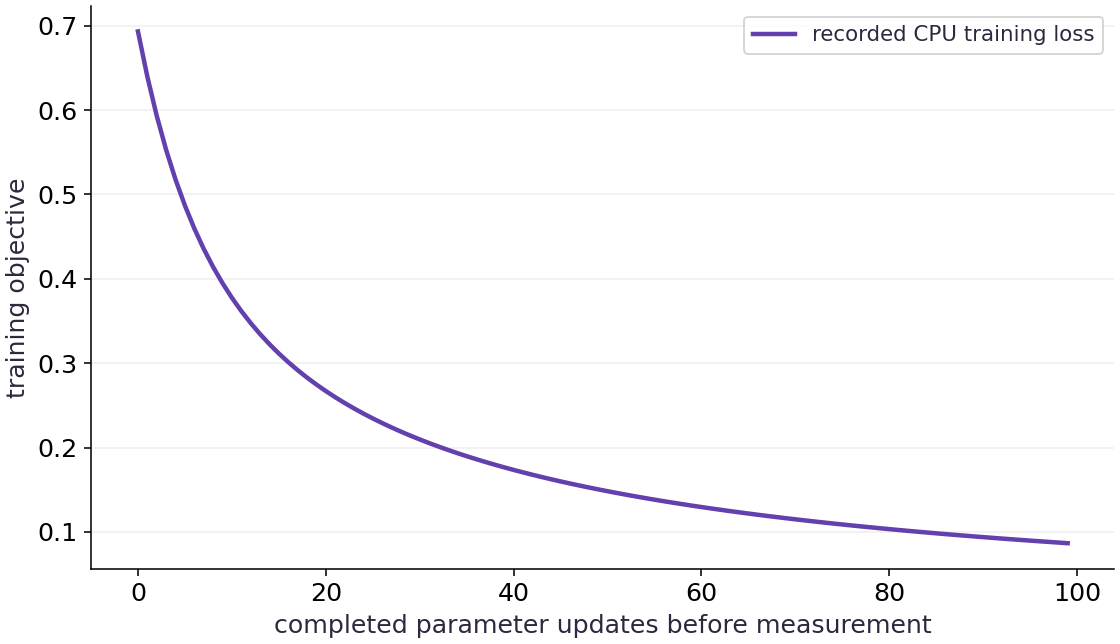

In [3]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data['unit'] in ('attention weight', 'next-token probability'):
            kw.update(vmin=0, vmax=1)
        device_ids = 'device ID' in data['unit']
        if device_ids:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            ids=np.unique(a).astype(int)
            kw.update(cmap=ListedColormap(palette[:len(ids)]), norm=BoundaryNorm(np.arange(ids.min()-0.5,ids.max()+1.5),len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if device_ids else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The vertical axis is pairwise negative log likelihood in nats. It starts near $0.693=\log2$, then falls to about $0.087$. Each point is before an update on the same three synthetic comparisons; it is not a human agreement rate.

### Connect it to the computation

The initial zero weights tie all response scores. Training increases the chosen-minus-rejected margins. The offset and scaling exercises explain why reward values must be interpreted relative to their model and downstream objective.

## Reverse the comparison

Predict: How should a positive margin change when chosen and rejected responses swap?

In [4]:
forward=float(preference_loss(w,chosen,rejected))
reverse=float(preference_loss(w,rejected,chosen))
assert reverse>forward
print('Forward/reversed preference NLL:',forward,reverse)

Forward/reversed preference NLL: 0.08596369624137878 2.94565486907959


Expected: The reversed-label loss is larger.

This checks label direction. A decreasing incorrectly signed loss can train a consistent but reversed preference model.

## Your exercise

Calculate the initial loss for tied reward scores independently and verify the trained ordering.

In [5]:
# Write your attempt here.

## Reference solution

Try your own implementation first.

In [6]:
np.testing.assert_allclose(preference_loss(jnp.zeros(2),chosen,rejected),-np.log(.5),atol=1e-6)
assert np.all(np.asarray((chosen-rejected)@w)>0)
print('Tied baseline and preference directions verified.')

Tied baseline and preference directions verified.


## Show that feature scale can change scores without changing ranking · Transfer

Multiply the trained reward weights by two and compare ordering and preference probabilities.

Hint: Positive scaling preserves ordering but sharpens probabilities.

In [7]:
# Write your attempt here.

## Reference reasoning

A policy’s reward-versus-KL tradeoff depends on reward scale. Rank agreement alone cannot establish an equivalent RL objective.

In [8]:
scaled_rewards=features@(2*w)
np.testing.assert_array_equal(np.argsort(rewards),np.argsort(scaled_rewards))
assert float(preference_loss(2*w,chosen,rejected))<float(preference_loss(w,chosen,rejected))
print('Ranking unchanged; confidence and downstream reward scale change.')

Ranking unchanged; confidence and downstream reward scale change.


## Checkpoint

What do pairwise preferences identify directly?

1. Reward differences under the chosen comparison model, not an absolute universal utility.
2. A lower training loss by itself proves the full application is ready.
3. Matching shapes alone establishes the required behavior.

## Diagnose

If margins have the wrong sign, inspect chosen/rejected order. If training ranking is perfect but held-out agreement fails, inspect prompt leakage, rubric consistency and reward-model overfitting.

## Evidence

Keep synthetic label provenance, stable preference-loss and gradient references, offset/scale tests and the learned ordering.

## Primary references

- [InstructGPT: reward modeling from preferences](https://arxiv.org/abs/2203.02155)